## Chapter 8: Beyond Linear Models
### Section B: Logistic Regression and Poisson Regression
#### MA189 Statistics and Big Data in Birmingham (with R)
##### -- _Blazer Core: City as Classroom Series_


Course Website: [github.com/tphilli2/datadiveintobirmingham](https://github.com/tphilli2/datadiveintobirmingham) 


#### Levels:
<div class="alert-success"> Concepts and general information</div>
<div class="alert-warning"> Important methods and technique details </div>
<div class="alert-info"> Extended reading </div>
<div class="alert-danger"> (Local) Examples, assignments, and <b>Practice in Birmingham</b> </div>

#### <div class="alert alert-block alert-success"> Introduction </div>

In this section, we will learn about two types of regression models commonly used for data where the response variable is not continuous quantitative:
1. **Logistic Regression** - For binary or categorical outcomes.
2. **Poisson Regression** - For count data.

Both methods extend the linear model framework to accommodate different types of dependent variables and can handle cases where linear regression is not appropriate.

<div class="alert alert-block alert-danger">
    <b>Application in Birmingham from Area of Insurance </b>
</div>

Consider the video below from Emma Keenum at __Protective Life__ discussing logistic regression in the case of life insurance underwriting and pursuing an accelerated process to save resources by identifying least risky applicants. 


[![Video: Protective Life Logistic Regression](https://youtu.be/w9VVAyIg6p4)](https://youtu.be/w9VVAyIg6p4)

#### <div class="alert alert-block alert-success"> Objectives </div>
1. Understand when to use logistic regression and how to fit and interpret a logistic regression model in R.
2. Understand when to use Poisson regression and how to fit and interpret a Poisson regression model in R.

Apply these methods to real data for hands-on practice.

#### <div class="alert alert-block alert-success"> Converting Variables</div>

Before building models, we often need to convert variables between different types. For logistic regression, the response variable should be binary, while predictors can be numeric or factors.

Here’s how to convert variables in R:

- **Numeric/Character to Factor**: `as.factor()`
- **Factor to Numeric**: `as.numeric()`
- **Factor to Character**: `as.character()`

In [42]:
# Example dataset: mtcars
data(mtcars)
head(mtcars)

# Creates new column called high_mpg that breaks up mgp into binary high and low categories
mtcars$high_mpg <- ifelse(mtcars$mpg > 20, "High", "Low")
head(mtcars)

# Convert the binary response variable to a factor so can be treated 
# like a category
mtcars$high_mpg <- as.factor(mtcars$high_mpg)  
head(mtcars)
# Check conversion
str(mtcars$high_mpg)

# Convert a predictor (such as cyl) to factor, if needed
mtcars$cyl <- as.factor(mtcars$cyl)
head(mtcars)
# Check conversion
str(mtcars$cyl)

# Convert back to numeric (such as cyl) if needed
#mtcars$cyl <- as.numeric(mtcars$cyl)
#head(mtcars)
# Check conversion
#str(mtcars$cyl)

# Convert back to numeric (such as cyl) with new column if needed
#mtcars$cyl_numeric <- as.numeric(mtcars$cyl)
#head(mtcars)
# Check conversion
#str(mtcars$cyl)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,high_mpg
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4,High
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4,High
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1,High
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1,High
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2,Low
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1,Low


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,high_mpg
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4,High
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4,High
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1,High
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1,High
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2,Low
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1,Low


 Factor w/ 2 levels "High","Low": 1 1 1 1 2 2 2 1 1 2 ...


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,high_mpg
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4,High
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4,High
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1,High
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1,High
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2,Low
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1,Low


 Factor w/ 3 levels "4","6","8": 2 2 1 2 3 2 3 1 1 2 ...


#### <div class="alert alert-block alert-success"> Generating Model Matrix with Factors </div>

To create a **model matrix** for logistic regression with factors, we can use the `model.matrix()` function. This function automatically converts factors to dummy variables (one-hot encoding).

For instance, suppose we want to build a logistic model with `cyl` as a factor.

In [43]:
# Create a model matrix with factor variables
model_matrix <- model.matrix(high_mpg ~ wt + hp + cyl, data = mtcars)

# View the generated matrix
head(model_matrix)
# cyl4 has become dummy variable/baseline variable so dropped 

,(Intercept),wt,hp,cyl6,cyl8
Mazda RX4,1,2.620,110,1,0
Mazda RX4 Wag,1,2.875,110,1,0
Datsun 710,1,2.320,93,0,0
Hornet 4 Drive,1,3.215,110,1,0
Hornet Sportabout,1,3.440,175,0,1
Valiant,1,3.460,105,1,0


### <div class="alert alert-block alert-success"> Logistic Regression </div>

Logistic regression is used when the response variable is **binary** (e.g., yes/no, success/failure). Instead of modeling the response as a linear function, we model the **log-odds** of the response as a linear function of the predictors. (This means that we will exponentiate afterwards to obtain the odds of a response variable occuring when a predictor variable changes). 

#### Logistic Regression Equation
The logistic regression model for a binary outcome $Y$ is:
$$
\text{logit}(P(Y=1)) = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_pX_p
$$
where:
- $\text{logit}(P) = \log\left(\frac{P}{1 - P}\right)$ is the log-odds
- $P(Y=1)$ is the probability that the response equals 1.


We'll demonstrate logistic regression using the `mtcars` dataset by creating a binary outcome variable, `high_mpg`, which indicates if a car has high fuel efficiency (or not). The logistic regression model will allow us to calculate the odds of a car having high fuel efficiency based on changes in predictor variables.

In [44]:
# Load necessary library
library(ggplot2)

# Create a binary outcome variable for high mpg (fuel efficiency)
mtcars$high_mpg <- ifelse(mtcars$mpg > 20, 1, 0)
# using 1s and 0s instead of high and low

# Preview the modified dataset
head(mtcars)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,high_mpg
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4,1
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4,1
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2,0
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1,0


#### <div class="alert alert-block alert-success"> Fitting a Logistic Regression Model </div>

We'll fit a logistic regression model to predict `high_mpg` based on the weight (`wt`) and horsepower (`hp`) of the cars. The `glm()` function in R with `family = binomial` is used for logistic regression.

In [45]:
?glm
#can run this to understand inputs of glm() in R

In [46]:
# Fit logistic regression model
logistic_model <- glm(high_mpg ~ wt + hp, data = mtcars, family = binomial)

# Summary of the logistic regression model
summary(logistic_model)

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ wt + hp, family = binomial, data = mtcars)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)    894.228 365884.162   0.002    0.998
wt            -202.865  84688.218  -0.002    0.998
hp              -2.021    858.062  -0.002    0.998

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4.3860e+01  on 31  degrees of freedom
Residual deviance: 1.1156e-08  on 29  degrees of freedom
AIC: 6

Number of Fisher Scoring iterations: 25


#### <div class="alert alert-block alert-warning"> Interpreting Logistic Regression Results </div>

The logistic regression model output includes coefficients for `wt` and `hp`. Here’s how to interpret the results:
1. **Coefficients**: Each coefficient represents the log-odds of `high_mpg` for a one-unit increase in the predictor, holding other predictors constant. This coefficient is not as practically understandable as the odds ratio so we use the odds ratio to interpret for our scenario. 
2. **Odds Ratios**: By exponentiating the coefficients, we obtain the odds ratios, which indicate the multiplicative change in odds for each unit increase in the predictor. (Not addition/subtraction but instead multiplication. For example, if the odds ratio for a certain predictor variable is $e^{0.7}≈2.01$, this means that for a one unit increase in the predictor, the odds of the outcome (high_mpg) are about 2 times higher, holding other predictor variables constant).

In [47]:
exp(coef(logistic_model))

(Intercept)           wt           hp 
         Inf 7.884361e-89 1.325092e-01

So a one unit increase in the wt results in almost a 100% decrease in likelihood of high mpg (so the opposite effect - much more likely it has a low mpg). And a one unit increase in hp results in a 87% decrease in likelihood of high mpg. 

The p-values for wt and hp are high because the standard errors of the coefficients are extremely large. This happens due to complete separation, where the model tries to fit the data almost exactly, leading to large (and unreliable) coefficient estimates. This often results in coefficients diverging towards infinity or being highly inflated. 
So the predictor variables in this example are not statistically significant in predicting the response variable.

#### <div class="alert alert-block alert-success"> Making Predictions with Logistic Regression </div>

Once the model is fit, we can use it to make predictions. Logistic regression outputs the probability of the outcome being 1 (a success), which we can threshold to predict binary outcomes.

In [48]:
# Predict probabilities of high mpg
predicted_probs <- predict(logistic_model, type = "response")

# Add predictions to the dataset with various sets of conditions/variable values given;
# if probability is greater than 0.5, assigned a success (1)
# of a high mpg 
mtcars$predicted_high_mpg <- ifelse(predicted_probs > 0.5, 1, 0)

# Display the first few rows with predictions
head(mtcars[, c("mpg", "wt", "hp", "high_mpg", "predicted_high_mpg")])

#mtcars[, c("mpg", "wt", "hp", "high_mpg", "predicted_high_mpg")]
# to see whole dataset 

# We can see the model predictions match what we expect

,mpg,wt,hp,high_mpg,predicted_high_mpg
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,2.620,110,1,1
Mazda RX4 Wag,21.0,2.875,110,1,1
Datsun 710,22.8,2.320,93,1,1
Hornet 4 Drive,21.4,3.215,110,1,1
Hornet Sportabout,18.7,3.440,175,0,0
Valiant,18.1,3.460,105,0,0


In [49]:
predicted_probs
#the value of the actual predicted_probs (which then got categorized into 0 or 1)
#based on 0.5 threshold but used to calculate mean square error below by comparing to 
#what the actual value was for the high_mpg: whether it was 0 or 1 

Mazda RX4       Mazda RX4 Wag          Datsun 710      Hornet 4 Drive 
       1.000000e+00        1.000000e+00        1.000000e+00        1.000000e+00 
  Hornet Sportabout             Valiant          Duster 360           Merc 240D 
       2.220446e-16        2.273598e-09        2.220446e-16        1.000000e+00 
           Merc 230            Merc 280           Merc 280C          Merc 450SE 
       1.000000e+00        2.220446e-16        2.220446e-16        2.220446e-16 
         Merc 450SL         Merc 450SLC  Cadillac Fleetwood Lincoln Continental 
       2.220446e-16        2.220446e-16        2.220446e-16        2.220446e-16 
  Chrysler Imperial            Fiat 128         Honda Civic      Toyota Corolla 
       2.220446e-16        1.000000e+00        1.000000e+00        1.000000e+00 
      Toyota Corona    Dodge Challenger         AMC Javelin          Camaro Z28 
       1.000000e+00        2.220446e-16        2.220446e-16        2.220446e-16 
   Pontiac Firebird           Fiat X1-9       Porsche 914-2        Lotus Europa 
       2.220446e-16        1.000000e+00        1.000000e+00        1.000000e+00 
     Ford Pantera L        Ferrari Dino       Maserati Bora          Volvo 142E 
       2.220446e-16        5.071730e-10        2.220446e-16        1.000000e+00

In [50]:
mse <- mean((mtcars$high_mpg - predicted_probs)^2)
cat("Training MSE:", mse, "\n")
#Mean squared error is very close to 0 so the model did a great job predicting

Training MSE: 4.141339e-19 


In [51]:
#if want to see how many cars with high_mpg fall into certain weight class (>3000 lbs)
table(mtcars$high_mpg, mtcars$wt > 3)

   
    FALSE TRUE
  0     1   17
  1    11    3

In [52]:
cor(mtcars$mpg,mtcars$wt)

[1] -0.8676594

#### <div class="alert alert-block alert-success"> Adding Higher-Order Terms and Interactions </div>

Higher-order terms (like squared terms) and interactions can capture complex relationships between variables.

1. **Higher-Order Terms**: To include polynomial terms, simply add the squared or cubed terms in the formula.
2. **Interactions**: Use `:` for interaction terms (e.g., `wt:hp`), or `*` as shorthand to include both individual and interaction terms (e.g., `wt * hp`).


In [53]:
# Include interaction in the model
model2 <- glm(high_mpg ~ wt + hp + wt:hp, family = binomial, data = mtcars)
summary(model2)
head(model.matrix(model2))

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ wt + hp + wt:hp, family = binomial, 
    data = mtcars)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)   1376.310 847009.895   0.002    0.999
wt            -384.770 240635.444  -0.002    0.999
hp              -7.017   4404.678  -0.002    0.999
wt:hp            1.847   1187.706   0.002    0.999

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4.3860e+01  on 31  degrees of freedom
Residual deviance: 4.7507e-09  on 28  degrees of freedom
AIC: 8

Number of Fisher Scoring iterations: 25


,(Intercept),wt,hp,wt:hp
Mazda RX4,1,2.620,110,288.20
Mazda RX4 Wag,1,2.875,110,316.25
Datsun 710,1,2.320,93,215.76
Hornet 4 Drive,1,3.215,110,353.65
Hornet Sportabout,1,3.440,175,602.00
Valiant,1,3.460,105,363.30


In [54]:
model3 <- glm(high_mpg ~ wt:hp, family = binomial, data = mtcars)
summary(model3)
head(model.matrix(model3))

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ wt:hp, family = binomial, data = mtcars)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)   1299.821 200677.927   0.006    0.995
wt:hp           -3.626    560.110  -0.006    0.995

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4.3860e+01  on 31  degrees of freedom
Residual deviance: 1.0096e-07  on 30  degrees of freedom
AIC: 4

Number of Fisher Scoring iterations: 25


,(Intercept),wt:hp
Mazda RX4,1,288.20
Mazda RX4 Wag,1,316.25
Datsun 710,1,215.76
Hornet 4 Drive,1,353.65
Hornet Sportabout,1,602.00
Valiant,1,363.30


In [55]:
model4 <- glm(high_mpg ~ wt + hp + wt*hp, family = binomial, data = mtcars)
summary(model4)
head(model.matrix(model4))

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ wt + hp + wt * hp, family = binomial, 
    data = mtcars)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)   1376.310 847009.895   0.002    0.999
wt            -384.770 240635.444  -0.002    0.999
hp              -7.017   4404.678  -0.002    0.999
wt:hp            1.847   1187.706   0.002    0.999

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4.3860e+01  on 31  degrees of freedom
Residual deviance: 4.7507e-09  on 28  degrees of freedom
AIC: 8

Number of Fisher Scoring iterations: 25


,(Intercept),wt,hp,wt:hp
Mazda RX4,1,2.620,110,288.20
Mazda RX4 Wag,1,2.875,110,316.25
Datsun 710,1,2.320,93,215.76
Hornet 4 Drive,1,3.215,110,353.65
Hornet Sportabout,1,3.440,175,602.00
Valiant,1,3.460,105,363.30


In [56]:
model5 <- glm(high_mpg ~ wt*hp, family = binomial, data = mtcars)
summary(model5)
head(model.matrix(model5))

Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ wt * hp, family = binomial, data = mtcars)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)
(Intercept)   1376.310 847009.895   0.002    0.999
wt            -384.770 240635.444  -0.002    0.999
hp              -7.017   4404.678  -0.002    0.999
wt:hp            1.847   1187.706   0.002    0.999

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4.3860e+01  on 31  degrees of freedom
Residual deviance: 4.7507e-09  on 28  degrees of freedom
AIC: 8

Number of Fisher Scoring iterations: 25


,(Intercept),wt,hp,wt:hp
Mazda RX4,1,2.620,110,288.20
Mazda RX4 Wag,1,2.875,110,316.25
Datsun 710,1,2.320,93,215.76
Hornet 4 Drive,1,3.215,110,353.65
Hornet Sportabout,1,3.440,175,602.00
Valiant,1,3.460,105,363.30


In [57]:
# Include high order in the model
model.high1 <- glm(high_mpg ~ I(wt^2), family = binomial, data = mtcars)
summary(model.high1)
head(model.matrix(model.high1))


Call:
glm(formula = high_mpg ~ I(wt^2), family = binomial, data = mtcars)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)  
(Intercept)  10.3523     4.3467   2.382   0.0172 *
I(wt^2)      -1.0521     0.4168  -2.524   0.0116 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 43.86  on 31  degrees of freedom
Residual deviance: 13.40  on 30  degrees of freedom
AIC: 17.4

Number of Fisher Scoring iterations: 8


,(Intercept),I(wt^2)
Mazda RX4,1,6.864400
Mazda RX4 Wag,1,8.265625
Datsun 710,1,5.382400
Hornet 4 Drive,1,10.336225
Hornet Sportabout,1,11.833600
Valiant,1,11.971600


In [58]:
model.high2 <- glm(high_mpg ~ I(wt^2) + wt, family = binomial, data = mtcars)
summary(model.high2)
head(model.matrix(model.high2))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ I(wt^2) + wt, family = binomial, data = mtcars)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)   -6.669     22.628  -0.295    0.768
I(wt^2)       -3.010      2.952  -1.020    0.308
wt            11.633     16.432   0.708    0.479

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 43.860  on 31  degrees of freedom
Residual deviance: 13.068  on 29  degrees of freedom
AIC: 19.068

Number of Fisher Scoring iterations: 8


,(Intercept),I(wt^2),wt
Mazda RX4,1,6.864400,2.620
Mazda RX4 Wag,1,8.265625,2.875
Datsun 710,1,5.382400,2.320
Hornet 4 Drive,1,10.336225,3.215
Hornet Sportabout,1,11.833600,3.440
Valiant,1,11.971600,3.460


In [59]:
# Include polynomial term in the model 
model.high3 <- glm(high_mpg ~ poly(wt,2,raw=TRUE), family = binomial, data = mtcars)
summary(model.high3)
head(model.matrix(model.high3))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ poly(wt, 2, raw = TRUE), family = binomial, 
    data = mtcars)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)
(Intercept)                -6.669     22.628  -0.295    0.768
poly(wt, 2, raw = TRUE)1   11.633     16.432   0.708    0.479
poly(wt, 2, raw = TRUE)2   -3.010      2.952  -1.020    0.308

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 43.860  on 31  degrees of freedom
Residual deviance: 13.068  on 29  degrees of freedom
AIC: 19.068

Number of Fisher Scoring iterations: 8


,(Intercept),"poly(wt, 2, raw = TRUE)1","poly(wt, 2, raw = TRUE)2"
Mazda RX4,1,2.620,6.864400
Mazda RX4 Wag,1,2.875,8.265625
Datsun 710,1,2.320,5.382400
Hornet 4 Drive,1,3.215,10.336225
Hornet Sportabout,1,3.440,11.833600
Valiant,1,3.460,11.971600


In [60]:
model.high4 <- glm(high_mpg ~ poly(wt,2) , family = binomial, data = mtcars)
summary(model.high4)
head(model.matrix(model.high4))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = high_mpg ~ poly(wt, 2), family = binomial, data = mtcars)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)  
(Intercept)    -3.191      2.663  -1.198   0.2308  
poly(wt, 2)1  -49.148     24.060  -2.043   0.0411 *
poly(wt, 2)2  -22.196     21.768  -1.020   0.3079  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 43.860  on 31  degrees of freedom
Residual deviance: 13.068  on 29  degrees of freedom
AIC: 19.068

Number of Fisher Scoring iterations: 8


,(Intercept),"poly(wt, 2)1","poly(wt, 2)2"
Mazda RX4,1,-0.1096309987,-0.04278415
Mazda RX4 Wag,1,-0.0628232889,-0.09005145
Datsun 710,1,-0.1646988925,0.03540332
Hornet 4 Drive,1,-0.0004130092,-0.12564085
Hornet Sportabout,1,0.0408879112,-0.13195337
Valiant,1,0.0445591041,-0.13185000


In [61]:
cor(model.matrix(model.high3)[,-1])
cor(model.matrix(model.high4)[,-1])

,"poly(wt, 2, raw = TRUE)1","poly(wt, 2, raw = TRUE)2"
"poly(wt, 2, raw = TRUE)1",1.0000000,0.9810937
"poly(wt, 2, raw = TRUE)2",0.9810937,1.0000000


,"poly(wt, 2)1","poly(wt, 2)2"
"poly(wt, 2)1",1.000000e+00,1.621966e-16
"poly(wt, 2)2",1.621966e-16,1.000000e+00


#### <div class="alert alert-block alert-success"> Visualizing Logistic Regression Predictions </div>

Visualization can help interpret logistic regression by showing predicted probabilities for different values of predictors.

We’ll use `ggplot2` to visualize predicted probabilities for `high_mpg` based on `wt`.

`geom_smooth()` using formula = 'y ~ x'


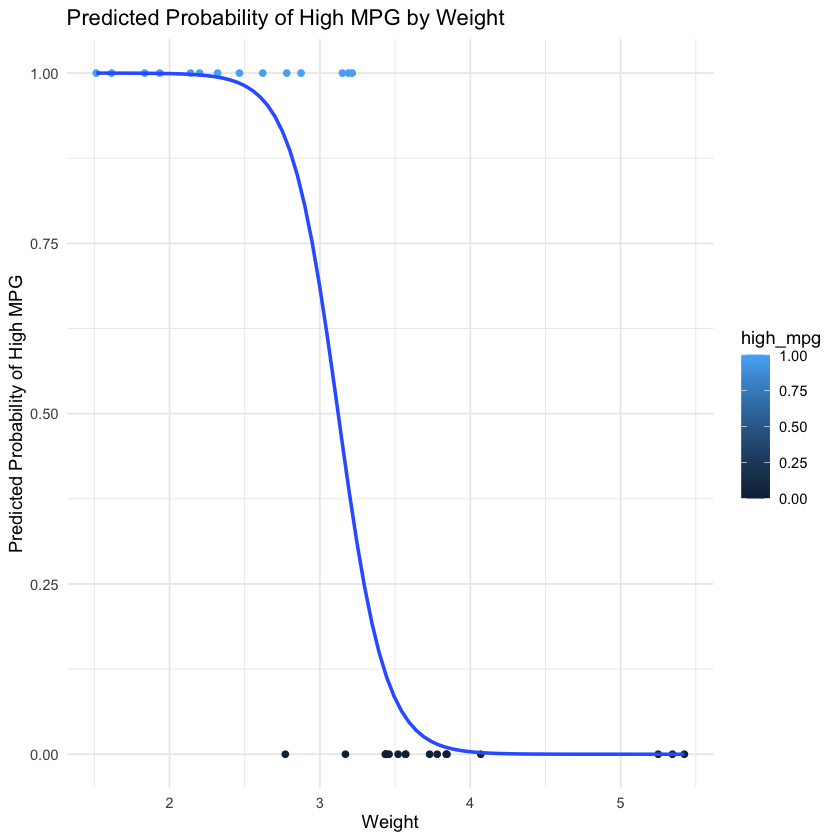

In [62]:
# Load ggplot2
library(ggplot2)

# Generate predicted probabilities for logistic regression model
mtcars$predicted_prob <- predict(logistic_model, type = "response")

# Plot predicted probabilities by weight (wt)
ggplot(mtcars, aes(x = wt, y = predicted_prob)) +
  geom_point(aes(color = high_mpg)) +
  geom_smooth(method = "glm", method.args = list(family = "binomial"), se = FALSE) +
  labs(title = "Predicted Probability of High MPG by Weight",
       x = "Weight", y = "Predicted Probability of High MPG") +
  theme_minimal()

# shows how increasing weight results in a lower predicted probability of high mpg 

### <div class="alert alert-block alert-success"> Poisson Regression </div>

Poisson regression is used when the response variable represents **count data** (e.g., number of occurrences of an event). Instead of modeling the response as a linear function, we model the **log of the expected count** as a linear function of the predictors. (This means we will exponentiate later to calculate the expected count of the response variable when a predictor variable changes). 

#### Poisson Regression Equation
The Poisson regression model for a count outcome $Y$ is:
$$
\log(\lambda) = \beta_0 + \beta_1X_1 + \beta_2X_2 + \dots + \beta_pX_p
$$
where:
- $\lambda$ is the expected count for a given set of predictor values.
- The log link function ensures that predicted counts are positive (because will exponentiate to get $\lambda$).

We'll use a hypothetical count variable `gear_counts` in `mtcars` for demonstration purposes, assuming it represents the number of times the car changes gear over 100 miles observed in a sample. The regression model will allow us to calculate the the multiplicative increase/decrease in the expected count (or value) of gear_counts based on changes in predictor variables.

In [66]:
# Create a count outcome variable (hypothetical) for demonstration
# call it gear_counts as example: 
# randomly produced data from poisson distribution with mean 2
mtcars$gear_counts <- rpois(n = nrow(mtcars), lambda = 2)

# Preview the modified dataset
head(mtcars)

# Note: set.seed is a random number generator that you can reproduce
# the results if you use the same number inside as the input 
# set.seed(42)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,high_mpg,predicted_high_mpg,predicted_prob,gear_counts
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4,1,1,1.000000e+00,1
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4,1,1,1.000000e+00,0
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1,1,1,1.000000e+00,7
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1,1,1,1.000000e+00,3
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2,0,0,2.220446e-16,0
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1,0,0,2.273598e-09,4


#### <div class="alert alert-block alert-success"> Fitting a Poisson Regression Model </div>

We'll fit a Poisson regression model to predict `gear_counts` based on weight (`wt`) and horsepower (`hp`). The `glm()` function in R with `family = poisson` is used for Poisson regression.

In [67]:
# Fit Poisson regression model
poisson_model <- glm(gear_counts ~ wt + hp, data = mtcars, family = poisson)

# Summary of the Poisson regression model
summary(poisson_model)


Call:
glm(formula = gear_counts ~ wt + hp, family = poisson, data = mtcars)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)  
(Intercept)  1.0776020  0.4606102   2.340   0.0193 *
wt          -0.1464166  0.1936209  -0.756   0.4495  
hp          -0.0004059  0.0027242  -0.149   0.8815  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 45.338  on 31  degrees of freedom
Residual deviance: 43.952  on 29  degrees of freedom
AIC: 114.67

Number of Fisher Scoring iterations: 5


####  <div class="alert alert-block alert-warning"> Interpreting Poisson Regression Results </div>

The Poisson regression model output includes coefficients for `wt` and `hp`. Here’s how to interpret the results:
1. **Coefficients**: Each coefficient represents the log of the expected count change for a one-unit increase in the predictor, holding other predictors constant.
2. **Rate Ratios**: By exponentiating the coefficients, we obtain rate ratios, which indicate the multiplicative change in the expected count for each unit increase in the predictor. (Not addition/subtraction but instead a multiplicative increase/decrease in response variable such as $e^{0.3}=1.35$ means a 35% increase in the response variable holding other predictor variables constant). 

#### R Code to Calculate Rate Ratios

In [68]:
# Exponentiate coefficients to get rate ratios
exp(coef(poisson_model))

(Intercept)          wt          hp 
  2.9376267   0.8637978   0.9995942

### <div class="alert alert-block alert-danger"><b>Practice Exercise</b></div>

Now it’s your turn to practice logistic and Poisson regression techniques.

#### Logistic Regression
1. Choose a binary variable as your target, such as `high_mpg`.
2. Fit a logistic regression model with two predictors.
3. Interpret the coefficients and calculate the odds ratios.

#### Poisson Regression
1. Choose a count variable as your target, or create one similar to `gear_counts`.
2. Fit a Poisson regression model with two predictors.
3. Interpret the coefficients and calculate the rate ratios.

#### Questions to Consider:
- How do the logistic and Poisson regression models differ in interpretation?
- What real-life scenarios would be suited for logistic regression? For poisson regression?

**Tip**: Use the example code above to guide your analysis. Try using other datasets to strengthen your understanding of these methods.